### Import bibliotek i podstawowa konfiguracja

In [23]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)


ADOPTION_SPEED_LABELS = {
    0: '0–7',
    1: '8–30',
    2: '31–90',
    3: '>100',
}
CLASS_ORDER = sorted(ADOPTION_SPEED_LABELS.keys())
CLASS_NAMES = [ADOPTION_SPEED_LABELS[c] for c in CLASS_ORDER]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


### Wczytanie i przygotowanie danych

In [24]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = Path('../models')
INPUT_PATH = f'{PROCESSED_DIR}/train_clean_anomaly.csv'

df = pd.read_csv(INPUT_PATH)

# Nie dodajemy do modelu rekordów-anomalii
if 'is_anomaly' in df.columns:
    df = df.drop(columns=['is_anomaly'])

y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])


# Kodowanie kolumn tekstowych
text_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
for col in text_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

feature_names = X.columns.tolist()

print('Podgląd danych:')
display(df.head())


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'\nX_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')


# Rozkład klas
class_distribution = pd.DataFrame({
    'y (całość) %': (y.value_counts(normalize=True).sort_index() * 100).round(2),
    'y_train %': (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    'y_test %': (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})
class_distribution.index.name = 'AdoptionSpeed'

print('Rozkład klas AdoptionSpeed (%):')
display(class_distribution)

Podgląd danych:


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Dewormed,Sterilized,Health,Quantity,Fee,VideoAmt,PhotoAmt,AdoptionSpeed,HasName,DescLength
0,2,3,299,0,1,1,7,0,1,1,...,2,2,1,1,100,0,1.0,1,1,359
1,2,1,265,0,1,1,2,0,2,2,...,3,3,1,1,0,0,2.0,0,1,118
2,1,1,307,0,1,2,7,0,2,2,...,1,2,1,1,0,0,7.0,2,1,393
3,1,4,307,0,2,1,2,0,2,1,...,1,2,1,1,150,0,8.0,1,1,146
4,1,1,307,0,1,1,0,0,2,1,...,2,2,1,1,0,0,3.0,1,1,390



X_train: (11875, 20), y_train: (11875,)
X_test:  (2969, 20), y_test:  (2969,)
Rozkład klas AdoptionSpeed (%):


,y (całość) %,y_train %,y_test %
AdoptionSpeed,,,
0,23.40,23.40,23.41
1,26.90,26.91,26.88
2,21.62,21.62,21.62
3,28.08,28.08,28.09


### Random Forest

Classification report
              precision    recall  f1-score   support

         0–7       0.41      0.41      0.41       695
        8–30       0.36      0.35      0.35       798
       31–90       0.35      0.24      0.28       642
        >100       0.49      0.62      0.55       834

    accuracy                           0.42      2969
   macro avg       0.40      0.40      0.40      2969
weighted avg       0.41      0.42      0.41      2969

Accuracy: 0.4160


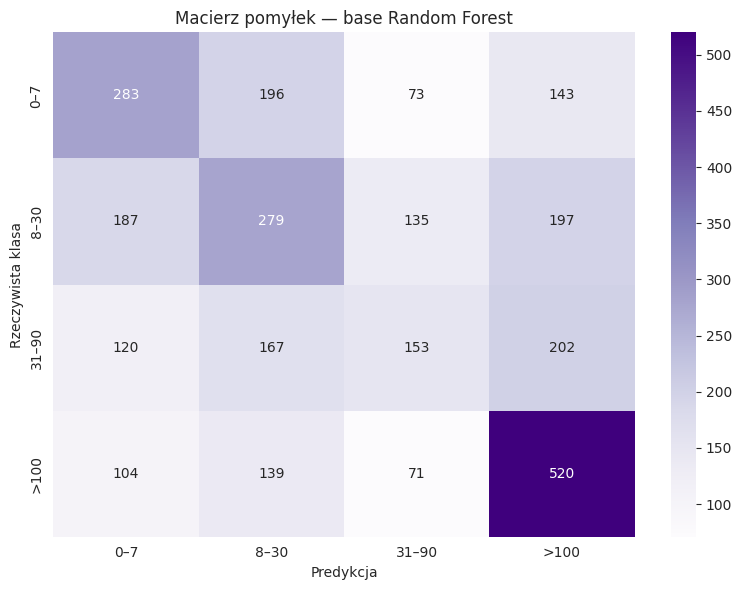

In [25]:
rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average='macro')

print('Classification report')
print(classification_report(
    y_test,
    y_pred_base,
    target_names=CLASS_NAMES,
))
print(f'Accuracy: {acc_base:.4f}')

cm_base = confusion_matrix(y_test, y_pred_base, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Macierz pomyłek — base Random Forest')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Cross-validation

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    RandomForestClassifier(random_state=RANDOM_STATE),
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy',
)

print('Wyniki accuracy dla poszczególnych foldów:')
for i, score in enumerate(cv_scores, start=1):
    print(f'  Powtórzenie {i}: {score:.4f}')

print(f'\nŚrednia: {cv_scores.mean():.4f}')
print(f'Odchylenie std: {cv_scores.std():.4f}')
print(f'Zakres (średnia ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Wyniki accuracy dla poszczególnych foldów:
  Powtórzenie 1: 0.4021
  Powtórzenie 2: 0.4152
  Powtórzenie 3: 0.4017
  Powtórzenie 4: 0.3924
  Powtórzenie 5: 0.4147

Średnia: 0.4052
Odchylenie std: 0.0087
Zakres (średnia ± std): 0.4052 ± 0.0087


### Kalibracja

Najlepsze parametry:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}

Najlepszy wynik CV (accuracy): 0.4250

Porównanie na zbiorze testowym:


,accuracy,f1_macro
baseline,0.415965,0.398579
po GridSearchCV,0.409229,0.378434



=== Classification report (po kalibracji) ===
              precision    recall  f1-score   support

         0–7       0.40      0.37      0.39       695
        8–30       0.34      0.39      0.36       798
       31–90       0.45      0.15      0.22       642
        >100       0.46      0.66      0.54       834

    accuracy                           0.41      2969
   macro avg       0.41      0.39      0.38      2969
weighted avg       0.41      0.41      0.39      2969



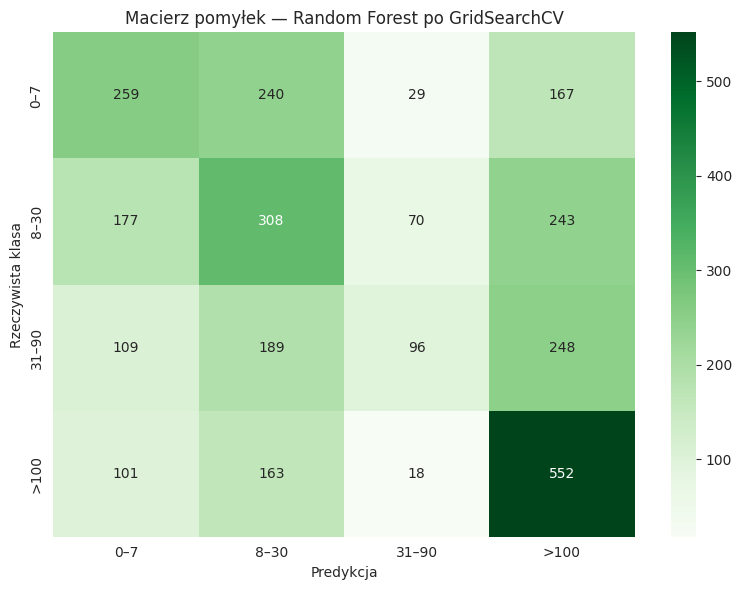

In [27]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print('Najlepsze parametry:')
print(grid_search.best_params_)
print(f'\nNajlepszy wynik CV (accuracy): {grid_search.best_score_:.4f}')

rf_best = grid_search.best_estimator_
y_pred_tuned = rf_best.predict(X_test)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

comparison = pd.DataFrame({
    'accuracy': [acc_base, acc_tuned],
    'f1_macro': [f1_base, f1_tuned],
}, index=['baseline', 'po GridSearchCV'])

print('\nPorównanie na zbiorze testowym:')
display(comparison)

print('\n=== Classification report (po kalibracji) ===')
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=CLASS_NAMES,
))

cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Macierz pomyłek — Random Forest po GridSearchCV')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Zapis modelu